# Objectifs d'apprentissage – Semaine 8

À l'issue de cette semaine, l'étudiant sera capable de :

- **Définir** la Transformée de Fourier Discrète (DFT) et la Transformée de Fourier Rapide (FFT).
- **Comprendre** la relation entre la DTFT, la DFT et la FFT.
- **Appliquer** la FFT pour analyser le contenu fréquentiel de signaux numériques.
- **Expliquer** le phénomène de fuite spectrale (spectral leakage) et son origine.
- **Utiliser** des fenêtres (Hamming, Hanning, Blackman) pour réduire les fuites spectrales.
- **Choisir** une fenêtre adaptée en fonction du compromis résolution/dynamique.
- **Interpréter** les spectres d'amplitude et de phase obtenus par FFT.
- **Mettre en œuvre** des analyses spectrales avancées (zero-padding, chevauchement).

# 1. Rappels théoriques

## 1.1 Transformée de Fourier Discrète (DFT)

Pour une séquence de longueur $N$, $x[0], x[1], \ldots, x[N-1]$, la DFT est définie par :

$$ X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j 2\pi k n / N}, \quad k = 0, 1, \ldots, N-1 $$

La DFT échantillonne la DTFT $X(e^{j\omega})$ aux fréquences $\omega_k = 2\pi k / N$.

Transformée inverse :

$$ x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \, e^{j 2\pi k n / N} $$

## 1.2 FFT (Fast Fourier Transform)

La FFT est un algorithme efficace pour calculer la DFT en $O(N \log N)$ opérations au lieu de $O(N^2)$ pour la DFT directe.

En Python, `numpy.fft` et `scipy.fft` fournissent des implémentations optimisées.

## 1.3 Fuite spectrale (Spectral Leakage)

Lorsqu'on applique la DFT à un signal de durée finie, on tronque le signal (multiplication par une fenêtre rectangulaire). Cette troncature provoque des lobes secondaires dans le spectre : c'est la fuite spectrale.

## 1.4 Fenêtrage

Pour réduire la fuite spectrale, on multiplie le signal par une fenêtre qui s'atténue vers les bords (Hamming, Hanning, Blackman, etc.).

**Compromis** :
- Fenêtre rectangulaire : meilleure résolution, mais forte fuite spectrale.
- Fenêtres de Hamming/Hanning : réduction de la fuite, mais élargissement du lobe principal (résolution diminuée).
- Fenêtre de Blackman : très faible fuite, mais lobe principal encore plus large.

## 1.5 Zero-padding

Ajouter des zéros à la fin du signal avant la FFT permet d'augmenter le nombre de points fréquentiels (meilleure visualisation), mais n'améliore pas la résolution spectrale.

---

# 2. Démonstrations Python

## 2.1 DFT vs FFT : calcul et comparaison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift

print("Bibliothèques chargées.")

Bibliothèques chargées.


In [2]:
def dft(x):
    """Calcul direct de la DFT (complexité O(N^2))."""
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)
    return X

# Test avec un petit signal
N = 8
x = np.sin(2*np.pi*1*np.arange(N)/N) + 0.5*np.sin(2*np.pi*3*np.arange(N)/N)

X_dft = dft(x)
X_fft = fft(x)

print("DFT directe (premiers termes) :", X_dft[:4])
print("FFT (premiers termes) :", X_fft[:4])
print("Erreur max :", np.max(np.abs(X_dft - X_fft)))

# Comparaison des temps d'exécution (à décommenter)
# import time
# N_big = 512
# x_big = np.random.randn(N_big)
# t1 = time.time(); dft(x_big); t1 = time.time() - t1
# t2 = time.time(); fft(x_big); t2 = time.time() - t2
# print(f"DFT : {t1:.4f}s, FFT : {t2:.4f}s")

DFT directe (premiers termes) : [2.22044605e-16+0.00000000e+00j 5.55111512e-16-4.00000000e+00j
 3.43604627e-16+2.22044605e-16j 1.11022302e-16-2.00000000e+00j]
FFT (premiers termes) : [-1.3792751e-16-0.j -3.0616170e-16-4.j  3.0616170e-16-0.j
 -3.0616170e-16-2.j]
Erreur max : 4.446386098569607e-15


## 2.2 Fuite spectrale (Spectral Leakage)

Prenons un signal sinusoïdal dont la fréquence n'est pas alignée sur la grille fréquentielle de la FFT.

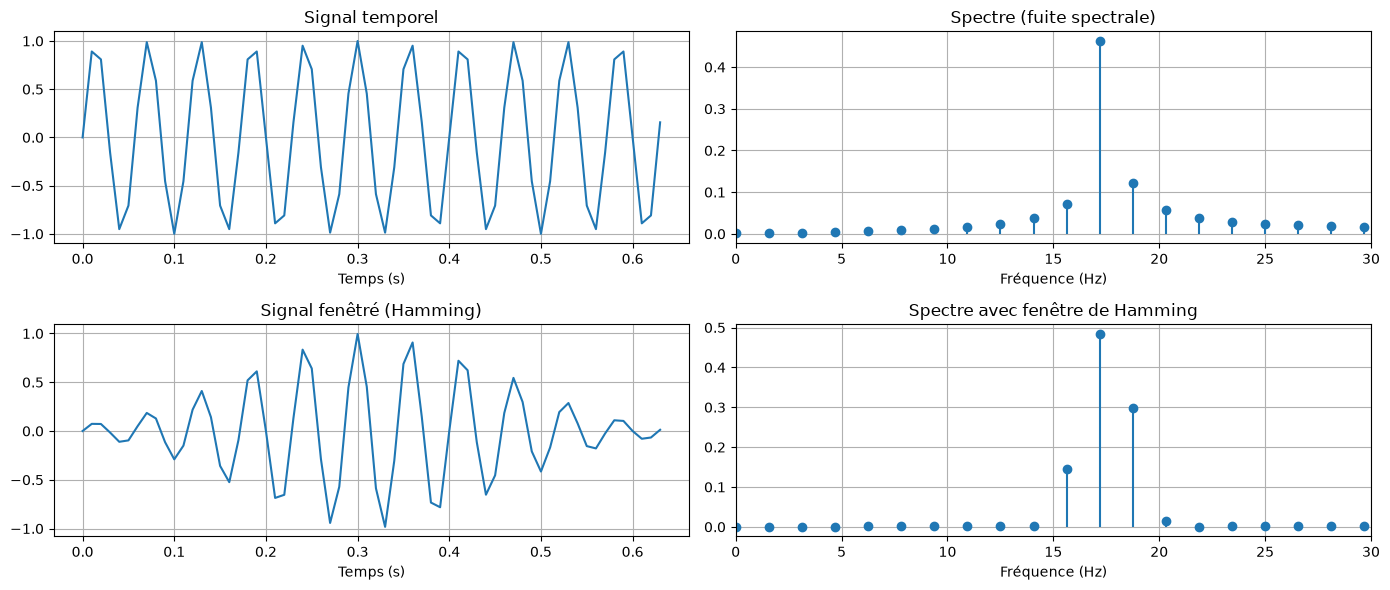

In [3]:
fs = 100  # Hz
N = 64   # nombre d'échantillons
f = 17.5  # Hz (fréquence non alignée : N*f/fs = 11.2, pas entier)
t = np.arange(N) / fs
x = np.sin(2*np.pi*f*t)

# FFT
X = fft(x)
freqs = fftfreq(N, 1/fs)

plt.figure(figsize=(14, 6))

plt.subplot(2, 2, 1)
plt.plot(t, x)
plt.title('Signal temporel')
plt.xlabel('Temps (s)')
plt.grid()

plt.subplot(2, 2, 2)
plt.stem(freqs[:N//2], np.abs(X[:N//2]) / N, basefmt=' ')
plt.title('Spectre (fuite spectrale)')
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 30)
plt.grid()

# Fenêtre de Hamming
window = np.hamming(N)
xw = x * window
Xw = fft(xw)

plt.subplot(2, 2, 3)
plt.plot(t, xw)
plt.title('Signal fenêtré (Hamming)')
plt.xlabel('Temps (s)')
plt.grid()

plt.subplot(2, 2, 4)
plt.stem(freqs[:N//2], np.abs(Xw[:N//2]) / np.sum(window), basefmt=' ')
plt.title('Spectre avec fenêtre de Hamming')
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 30)
plt.grid()

plt.tight_layout()
plt.show()

## 2.3 Comparaison des fenêtres

Visualisons différentes fenêtres et leurs réponses fréquentielles.

In [ ]:
N = 64
n = np.arange(N)

windows = {
    'Rectangulaire': np.ones(N),
    'Hamming': np.hamming(N),
    'Hanning': np.hanning(N),
    'Blackman': np.blackman(N),
    'Kaiser (beta=5)': np.kaiser(N, 5)
}

plt.figure(figsize=(14, 12))

for i, (name, w) in enumerate(windows.items()):
    # Réponse fréquentielle
    W = fft(w, 1024)
    W_mag = 20 * np.log10(np.abs(fftshift(W)) + 1e-12)
    freqs = np.linspace(-0.5, 0.5, 1024)
    
    plt.subplot(len(windows), 2, 2*i+1)
    plt.plot(n, w)
    plt.title(f'{name} (temporel)')
    plt.grid()
    
    plt.subplot(len(windows), 2, 2*i+2)
    plt.plot(freqs, W_mag)
    plt.title(f'{name} (fréquentiel)')
    plt.grid()
    plt.ylim(-80, 5)
    plt.xlim(-0.5, 0.5)

plt.tight_layout()
plt.show()

## 2.4 Zero-padding

Le zero-padding permet d'augmenter la résolution apparente du spectre (meilleure visualisation).

In [ ]:
fs = 100
N = 16
f = 10
t = np.arange(N) / fs
x = np.sin(2*np.pi*f*t) + 0.5*np.sin(2*np.pi*25*t)

N_ffts = [16, 64, 256]

plt.figure(figsize=(14, 5))
for i, N_fft in enumerate(N_ffts):
    X = fft(x, N_fft)
    freqs = fftfreq(N_fft, 1/fs)
    
    plt.subplot(1, 3, i+1)
    plt.stem(freqs[:N_fft//2], np.abs(X[:N_fft//2]) / N, basefmt=' ')
    plt.title(f'Zero-padding : N={N_fft}')
    plt.xlabel('Fréquence (Hz)')
    plt.xlim(0, 40)
    plt.grid()

plt.tight_layout()
plt.show()

# 3. Atelier : Analyse spectrale d'un signal réel

Nous allons appliquer les techniques vues ci-dessus à un signal audio (ou synthétique).

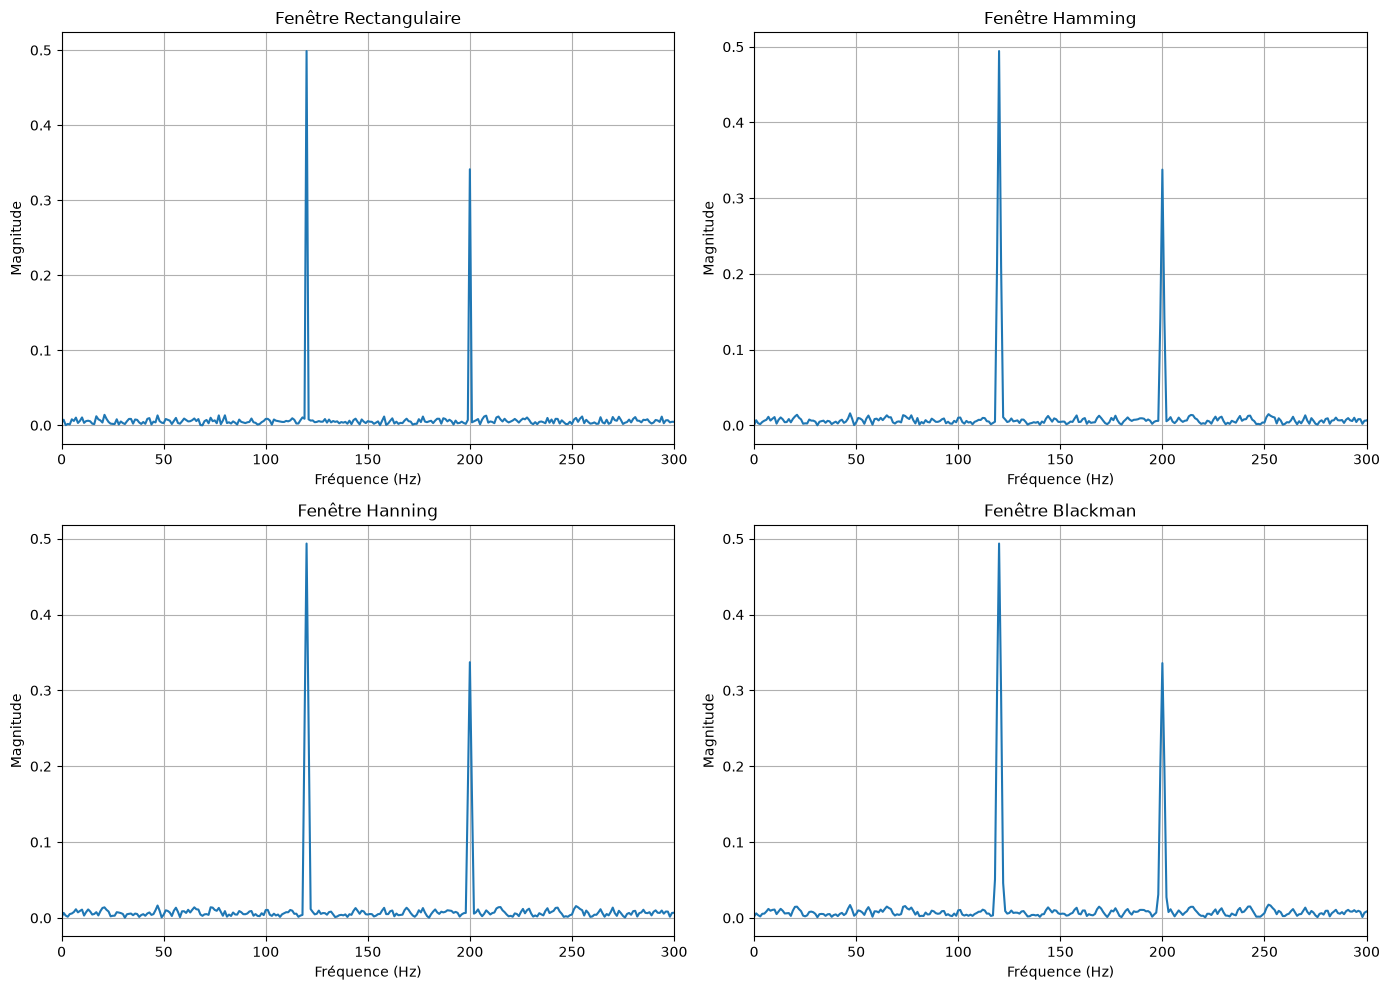

In [4]:
# Génération d'un signal de test : deux sinusoïdes + bruit
fs = 1000
duration = 1.0
t = np.linspace(0, duration, int(fs*duration), endpoint=False)

f1, f2 = 120, 200
x = np.sin(2*np.pi*f1*t) + 0.7*np.sin(2*np.pi*f2*t) + 0.2*np.random.randn(len(t))

# Analyse avec différentes fenêtres
N = len(x)
windows_test = {
    'Rectangulaire': np.ones(N),
    'Hamming': np.hamming(N),
    'Hanning': np.hanning(N),
    'Blackman': np.blackman(N)
}

plt.figure(figsize=(14, 10))

for i, (name, w) in enumerate(windows_test.items()):
    xw = x * w
    X = fft(xw)
    freqs = fftfreq(N, 1/fs)[:N//2]
    
    plt.subplot(2, 2, i+1)
    plt.plot(freqs, np.abs(X[:N//2]) / np.sum(w))
    plt.title(f'Fenêtre {name}')
    plt.xlabel('Fréquence (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, 300)
    plt.grid()

plt.tight_layout()
plt.show()

# 4. Exercices – Semaine 8

## Exercice 1 – DFT et FFT

1. Générer un signal $x[n] = \cos(2\pi f_0 n / f_s)$ pour $n=0,\dots,63$, avec $f_0 = 10$ Hz et $f_s = 64$ Hz.
2. Calculer la DFT manuellement pour quelques valeurs de $k$ (par exemple $k=0,1,2$).
3. Vérifier avec `numpy.fft.fft`.
4. Que vaut $X[10]$ ? Pourquoi ?

**Code** :

In [ ]:
N = 64
fs = 64
f0 = 10
n = np.arange(N)
x = np.cos(2*np.pi*f0*n/fs)

# DFT manuelle pour k=0,1,2
k_vals = [0, 1, 2]
for k in k_vals:
    Xk = np.sum(x * np.exp(-2j*np.pi*k*n/N))
    print(f"X[{k}] = {Xk:.2f}")

# Vérification avec FFT
X = fft(x)
print(f"X[10] (FFT) = {X[10]:.2f}")
print(f"X[54] (FFT) = {X[54]:.2f}")
# X[10] est non nul car 10 Hz correspond à k=10 (fréquence alignée)

## Exercice 2 – Fuite spectrale et fenêtrage

1. Générer $x[n] = \sin(2\pi f_1 n / f_s) + \sin(2\pi f_2 n / f_s)$ avec $f_1 = 15$ Hz, $f_2 = 16$ Hz, $f_s = 64$ Hz, $N=64$.
2. Calculer et tracer le spectre sans fenêtre.
3. Appliquer une fenêtre de Hamming et tracer le nouveau spectre.
4. Commenter la résolution et la fuite spectrale dans les deux cas.

**Code** :

In [ ]:
N = 64
fs = 64
n = np.arange(N)
f1, f2 = 15, 16
x = np.sin(2*np.pi*f1*n/fs) + np.sin(2*np.pi*f2*n/fs)

# Sans fenêtre
X = fft(x)
freqs = np.fft.fftfreq(N, 1/fs)[:N//2]

# Avec Hamming
xw = x * np.hamming(N)
Xw = fft(xw)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.stem(freqs, np.abs(X[:N//2]) / N, basefmt=' ')
plt.title('Sans fenêtre')
plt.xlabel('Fréquence (Hz)')
plt.xlim(10, 20)
plt.grid()

plt.subplot(1, 2, 2)
plt.stem(freqs, np.abs(Xw[:N//2]) / np.sum(np.hamming(N)), basefmt=' ')
plt.title('Avec Hamming')
plt.xlabel('Fréquence (Hz)')
plt.xlim(10, 20)
plt.grid()
plt.show()

## Exercice 3 – Choix de la fenêtre

On considère un signal composé de trois sinusoïdes très proches : 100.0 Hz, 100.5 Hz, 101.0 Hz.

1. Générer ce signal sur 1 seconde à $f_s = 500$ Hz.
2. Tester plusieurs fenêtres (rectangulaire, Hamming, Blackman).
3. Quelle fenêtre permet de distinguer les trois fréquences ? Quelle fenêtre donne la meilleure dynamique (lobes secondaires les plus faibles) ?
4. Proposer une stratégie pour améliorer la résolution.

**Code** :

In [ ]:
fs = 500
duration = 1.0
N = int(fs * duration)
t = np.linspace(0, duration, N, endpoint=False)

freqs_signal = [100.0, 100.5, 101.0]
x = np.zeros(N)
for f in freqs_signal:
    x += np.sin(2*np.pi*f*t)

windows = {
    'Rectangulaire': np.ones(N),
    'Hamming': np.hamming(N),
    'Hanning': np.hanning(N),
    'Blackman': np.blackman(N)
}

plt.figure(figsize=(14, 10))
for i, (name, w) in enumerate(windows.items()):
    xw = x * w
    X = fft(xw)
    freqs = fftfreq(N, 1/fs)[:N//2]
    
    plt.subplot(2, 2, i+1)
    plt.plot(freqs, 20*np.log10(np.abs(X[:N//2]) / np.sum(w) + 1e-12))
    plt.title(f'Fenêtre {name}')
    plt.xlabel('Fréquence (Hz)')
    plt.xlim(98, 103)
    plt.ylim(-80, 5)
    plt.grid()

plt.tight_layout()
plt.show()

# La fenêtre rectangulaire donne la meilleure résolution, mais les lobes secondaires sont élevés.
# Blackman donne la meilleure dynamique, mais une résolution moindre.
# Pour améliorer la résolution, il faut augmenter N (durée d'acquisition).

## Exercice 4 – Zero-padding et résolution

1. Générer $x[n] = \sin(2\pi 0.4 n) + \sin(2\pi 0.45 n)$ pour $n=0,\dots,31$.
2. Calculer la FFT avec différents zero-padding ($N_{fft} = 32, 64, 256$).
3. Observer l'effet du zero-padding sur le spectre.
4. Que se passe-t-il au niveau de la résolution ?

**Code** :

In [ ]:
N = 32
n = np.arange(N)
x = np.sin(2*np.pi*0.4*n) + np.sin(2*np.pi*0.45*n)

N_ffts = [32, 64, 256]

plt.figure(figsize=(14, 5))
for i, N_fft in enumerate(N_ffts):
    X = fft(x, N_fft)
    freqs = np.linspace(0, np.pi, N_fft//2)
    
    plt.subplot(1, 3, i+1)
    plt.plot(freqs, np.abs(X[:N_fft//2]) / N)
    plt.title(f'Zero-padding : N_fft={N_fft}')
    plt.xlabel('Fréquence (rad/échantillon)')
    plt.xlim(0.3, 0.55)
    plt.grid()

plt.tight_layout()
plt.show()

# Le zero-padding n'améliore pas la résolution (les deux pics restent confondus),
# mais il permet de mieux visualiser la forme du lobe.

## Exercice 5 – Spectre de phase et décalage temporel

1. Générer $x[n] = \cos(0.3\pi n)$ pour $n=0,\dots,31$.
2. Calculer le spectre de phase (argument de la FFT).
3. Décaler le signal de 3 échantillons ($y[n] = x[n-3]$) et recalculer le spectre de phase.
4. Observer la relation entre le décalage temporel et la phase de la FFT.

**Code** :

In [ ]:
N = 32
n = np.arange(N)
x = np.cos(0.3*np.pi*n)
y = np.roll(x, 3)  # décalage de 3

X = fft(x)
Y = fft(y)
freqs = np.linspace(0, np.pi, N//2)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs, np.unwrap(np.angle(X[:N//2])), label='Phase originale')
plt.plot(freqs, np.unwrap(np.angle(Y[:N//2])), label='Phase décalée')
plt.xlabel('Fréquence (rad/échantillon)')
plt.ylabel('Phase (rad)')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.stem(n, x, basefmt=' ', label='Original')
plt.stem(n, y, basefmt=' ', linefmt='r-', markerfmt='ro', label='Décalé de 3')
plt.legend()
plt.grid()
plt.show()

print("Le décalage temporel introduit un déphasage linéaire : phase_Y = phase_X - omega*3.")

## Exercice 6 – Analyse spectrale d'un fichier audio

1. Charger un fichier audio (WAV) ou utiliser un signal synthétique.
2. Afficher le signal temporel et son spectre avec une FFT.
3. Identifier les composantes fréquentielles principales.
4. Appliquer un filtre coupe-bande pour supprimer une fréquence parasite (exemple : 50 Hz).
5. Comparer les spectres avant et après filtrage.

**Code** (adaptez si vous avez un fichier audio) :

In [ ]:
# Exemple avec un signal synthétique contenant du bruit à 50 Hz
fs = 1000
duration = 2.0
t = np.linspace(0, duration, int(fs*duration), endpoint=False)

# Signal utile + bruit 50 Hz
x = np.sin(2*np.pi*120*t) + 0.5*np.sin(2*np.pi*50*t) + 0.1*np.random.randn(len(t))

# FFT
X = fft(x)
freqs = fftfreq(len(x), 1/fs)[:len(x)//2]

plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.plot(t[:500], x[:500])
plt.title('Signal temporel (extrait)')
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(freqs, np.abs(X[:len(x)//2]) / len(x))
plt.title('Spectre original')
plt.xlim(0, 200)
plt.grid()

# Filtrage simple : on supprime la composante 50 Hz dans le domaine fréquentiel
X_filtre = X.copy()
indices = np.where(np.abs(freqs - 50) < 0.5)[0]
X_filtre[indices] = 0
indices_neg = np.where(np.abs(freqs + 50) < 0.5)[0]
X_filtre[indices_neg + len(x)//2] = 0

x_filtre = np.fft.ifft(X_filtre).real

plt.subplot(2, 2, 3)
plt.plot(freqs, np.abs(X_filtre[:len(x)//2]) / len(x))
plt.title('Spectre filtré (50 Hz supprimé)')
plt.xlim(0, 200)
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(t[:500], x_filtre[:500])
plt.title('Signal filtré (extrait)')
plt.grid()

plt.tight_layout()
plt.show()

# 5. Livrable Semaine 8

- Remplir les cellules de code avec vos solutions.
- Répondre aux questions théoriques dans les cellules markdown.
- Inclure des commentaires explicatifs.
- Rendre le notebook complet (cellules exécutées).

**Date de rendu** : à définir par l'enseignant.

---